# Домашнее задание 1 — Кластеризация клиентов фитнес-клуба по составу тела

**Студент:** Парамонов Владислав Романович 409308


---
## Задание 1 — Постановка задачи

### 1.1 Бизнес-постановка задачи

Фитнес-клуб хочет лучше понимать своих клиентов и персонализировать работу с ними. На основе данных о составе тела (процент жира, мышечная масса, ИМТ, ЧСС, калории и т.д.) и поведенческих характеристик (тип тренировок, частота посещений, водный баланс) необходимо автоматически разбить клиентов на группы.

**Цель:** Выявить типовые профили клиентов, чтобы:
- Предлагать каждой группе персонализированную программу тренировок
- Выявлять клиентов в группе риска (высокий % жира + низкая активность)
- Оптимизировать маркетинговые предложения под каждый сегмент

**Аналогия с InBody:** Данный датасет по своей структуре близок к выгрузке показателей InBody-анализатора в фитнес-клубах — те же параметры состава тела (жир, мышцы, ИМТ) дополненные поведенческими данными о тренировках.

### 1.2 ML-постановка задачи

**Тип задачи:** Кластеризация (обучение без учителя / Unsupervised Learning)

**Алгоритм:** K-Means — разбивает клиентов на K групп так, чтобы объекты внутри одной группы были максимально похожи между собой.

**Входные признаки:**
- `Weight (kg)` — вес клиента
- `Height (m)` — рост клиента  
- `Fat_Percentage` — процент жировой ткани (ключевой InBody-показатель)
- `BMI` — индекс массы тела
- `Max_BPM`, `Avg_BPM`, `Resting_BPM` — показатели сердечного ритма
- `Calories_Burned` — расход калорий за тренировку
- `Session_Duration (hours)` — длительность тренировки
- `Water_Intake (liters)` — водный баланс
- `Workout_Frequency (days/week)` — частота тренировок
- `Experience_Level` — уровень опыта (1=новичок, 3=эксперт)

**Количество кластеров K** подбирается с помощью метода локтя (Elbow method) и силуэтного коэффициента.

### 1.3 Датасет

**Источник:** [Gym Members Exercise Dataset](https://www.kaggle.com/datasets/valakhorasani/gym-members-exercise-dataset) — Kaggle

**Размер:** 973 записи, 15 признаков — удовлетворяет требованию курса

**Признаки:** демографические (пол, возраст), состав тела (вес, рост, ИМТ, % жира), сердечно-сосудистые показатели (ЧСС), поведенческие (тип тренировки, частота, длительность, вода, калории, опыт).

---
## Задание 2 — Метрика качества

**Основная метрика: Silhouette Score (Силуэтный коэффициент)**

$$s(i) = \frac{b(i) - a(i)}{\max(a(i), b(i))}$$

где $a(i)$ — среднее расстояние от объекта до остальных объектов своего кластера, $b(i)$ — минимальное среднее расстояние до объектов ближайшего чужого кластера.

**Значения:** от -1 до +1, чем выше — тем лучше разделены кластеры.

**Вспомогательная метрика: Inertia (метод локтя)**  
Сумма квадратов расстояний от объектов до центроидов их кластеров. Используется для подбора оптимального числа кластеров K.

**Обоснование (1–2 предложения):**  
Силуэтный коэффициент выбран как основная метрика, так как позволяет оценить компактность и разделимость кластеров без использования истинных меток — что принципиально важно для задачи обучения без учителя. Дополнительно используется метод локтя (inertia) для выбора оптимального числа кластеров K, что обеспечивает интерпретируемость результата с точки зрения бизнеса (например, 3–5 чётко выраженных профилей клиентов).

---
## Задание 3 — EDA (Разведочный анализ данных)

In [1]:
# Установка зависимостей (при необходимости)
!pip install pandas numpy seaborn plotly scikit-learn openpyxl

In [2]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd

import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import matplotlib.pyplot as plt
from matplotlib.cbook import boxplot_stats

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

sns.set_theme(style='whitegrid')
%matplotlib inline

print('Библиотеки загружены успешно!')

Библиотеки загружены успешно!


### 3.1 Загрузка и первичное знакомство с данными

Для запуска датасета нужно иметь аккаунт на Kaggle и иметь API Token  
Мой Kaggle username: ogvladik  
Мой Kaggle Key: KGAT_8ecff861bb739fcbaba574190166c794

In [3]:
# Установка библиотеки
!pip install opendatasets -q

import opendatasets as od
import pandas as pd

# Загрузка датасета
print("Загрузка датасета...")
od.download("https://www.kaggle.com/datasets/valakhorasani/gym-members-exercise-dataset")

# Чтение данных
df = pd.read_csv('gym-members-exercise-dataset/gym_members_exercise_tracking.csv')

# Проверка
print(f"\n Размер датасета: {df.shape[0]} строк × {df.shape[1]} столбцов\n")
print(" Первые 5 строк:")
df.head()

Загрузка датасета...
Please provide your Kaggle credentials to download this dataset. Learn more: http://bit.ly/kaggle-creds
Your Kaggle username: ogvladik
Your Kaggle Key: ··········
Dataset URL: https://www.kaggle.com/datasets/valakhorasani/gym-members-exercise-dataset


100%|██████████| 21.6k/21.6k [00:00<00:00, 32.5MB/s]



 Размер датасета: 973 строк × 15 столбцов

 Первые 5 строк:


,Age,Gender,Weight (kg),Height (m),Max_BPM,Avg_BPM,Resting_BPM,Session_Duration (hours),Calories_Burned,Workout_Type,Fat_Percentage,Water_Intake (liters),Workout_Frequency (days/week),Experience_Level,BMI
0,56,Male,88.3,1.71,180,157,60,1.69,1313.0,Yoga,12.6,3.5,4,3,30.20
1,46,Female,74.9,1.53,179,151,66,1.30,883.0,HIIT,33.9,2.1,4,2,32.00
2,32,Female,68.1,1.66,167,122,54,1.11,677.0,Cardio,33.4,2.3,4,2,24.71
3,25,Male,53.2,1.70,190,164,56,0.59,532.0,Strength,28.8,2.1,3,1,18.41
4,38,Male,46.1,1.79,188,158,68,0.64,556.0,Strength,29.2,2.8,3,1,14.39


In [4]:
# Проверка пропущенных значений
missing = df.isna().sum()
print('Пропущенные значения по столбцам:')
print(missing[missing > 0] if missing.sum() > 0 else 'Пропущенных значений нет ')

Пропущенные значения по столбцам:
Пропущенных значений нет 


**Комментарий:** Датасет содержит 973 записи и 15 признаков. Пропущенных значений нет, что упрощает предобработку. Данные представлены смешанным типом: числовые (вес, рост, ЧСС и т.д.) и категориальные (пол, тип тренировки). Это близко к реальным данным из InBody-анализаторов, где числовые показатели состава тела дополняются анкетными данными клиента.

### 3.2 Базовые статистики

In [5]:
# Числовые признаки — базовые статистики
num_cols = df.select_dtypes(include='number')
num_cols.describe().round(2)

,Age,Weight (kg),Height (m),Max_BPM,Avg_BPM,Resting_BPM,Session_Duration (hours),Calories_Burned,Fat_Percentage,Water_Intake (liters),Workout_Frequency (days/week),Experience_Level,BMI
count,973.00,973.00,973.00,973.00,973.00,973.00,973.00,973.00,973.00,973.00,973.00,973.00,973.00
mean,38.68,73.85,1.72,179.88,143.77,62.22,1.26,905.42,24.98,2.63,3.32,1.81,24.91
std,12.18,21.21,0.13,11.53,14.35,7.33,0.34,272.64,6.26,0.60,0.91,0.74,6.66
min,18.00,40.00,1.50,160.00,120.00,50.00,0.50,303.00,10.00,1.50,2.00,1.00,12.32
25%,28.00,58.10,1.62,170.00,131.00,56.00,1.04,720.00,21.30,2.20,3.00,1.00,20.11
50%,40.00,70.00,1.71,180.00,143.00,62.00,1.26,893.00,26.20,2.60,3.00,2.00,24.16
75%,49.00,86.00,1.80,190.00,156.00,68.00,1.46,1076.00,29.30,3.10,4.00,2.00,28.56
max,59.00,129.90,2.00,199.00,169.00,74.00,2.00,1783.00,35.00,3.70,5.00,3.00,49.84


In [6]:
# Категориальные признаки
cat_cols = df.select_dtypes(include='object')
print(f'Категориальные столбцы: {list(cat_cols.columns)}')
cat_cols.describe()

Категориальные столбцы: ['Gender', 'Workout_Type']


,Gender,Workout_Type
count,973,973
unique,2,4
top,Male,Strength
freq,511,258


**Комментарий:** Процент жира (`Fat_Percentage`) варьируется от ~10% до ~35% — широкий диапазон, что говорит о разнородной аудитории клуба. Средний BMI около 25–26 (граница нормы/избыточного веса). Уровень опыта распределён по трём группам (1, 2, 3), что потенциально может формировать естественные кластеры. Это важное наблюдение для интерпретации результатов кластеризации.

### 3.3 Анализ целевых переменных (показатели состава тела)

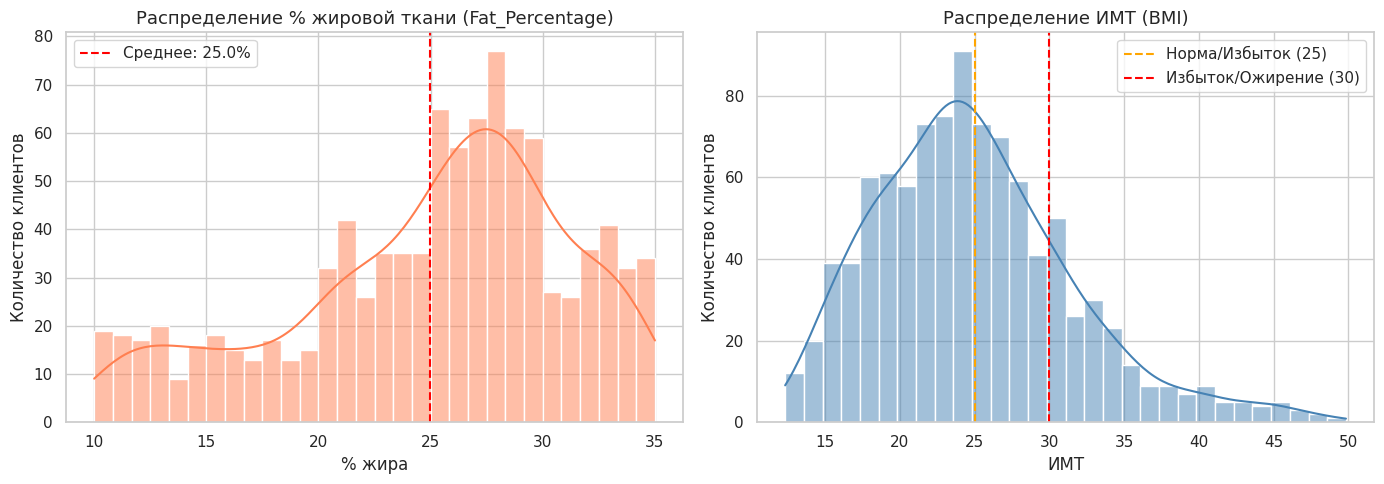

In [7]:
# Ключевые InBody-показатели: % жира и BMI
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(df['Fat_Percentage'], kde=True, ax=axes[0], color='coral', bins=30)
axes[0].set_title('Распределение % жировой ткани (Fat_Percentage)', fontsize=13)
axes[0].set_xlabel('% жира')
axes[0].set_ylabel('Количество клиентов')
axes[0].axvline(df['Fat_Percentage'].mean(), color='red', linestyle='--', label=f'Среднее: {df["Fat_Percentage"].mean():.1f}%')
axes[0].legend()

sns.histplot(df['BMI'], kde=True, ax=axes[1], color='steelblue', bins=30)
axes[1].set_title('Распределение ИМТ (BMI)', fontsize=13)
axes[1].set_xlabel('ИМТ')
axes[1].set_ylabel('Количество клиентов')
axes[1].axvline(25, color='orange', linestyle='--', label='Норма/Избыток (25)')
axes[1].axvline(30, color='red', linestyle='--', label='Избыток/Ожирение (30)')
axes[1].legend()

plt.tight_layout()
plt.savefig('fat_bmi_dist.png', dpi=150, bbox_inches='tight')
plt.show()

**Комментарий:** Распределение % жира близко к нормальному, что хорошо для кластеризации — алгоритмы K-Means предполагают примерно сферическую форму кластеров. Большинство клиентов находятся в диапазоне BMI 22–30, с небольшим «хвостом» в сторону ожирения. Эти два показателя являются ключевыми для сегментации по составу тела.

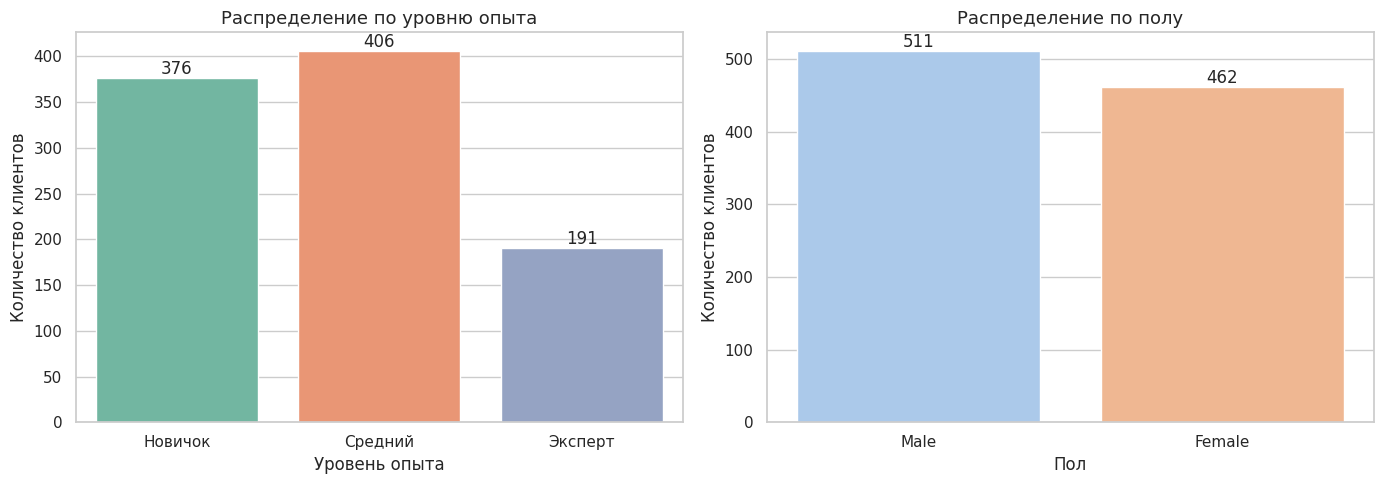

In [8]:
# Распределение по уровню опыта (Experience_Level)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

exp_labels = {1: 'Новичок', 2: 'Средний', 3: 'Эксперт'}
df['Experience_Label'] = df['Experience_Level'].map(exp_labels)

sns.countplot(x='Experience_Label', data=df, ax=axes[0],
              palette='Set2', order=['Новичок', 'Средний', 'Эксперт'])
axes[0].set_title('Распределение по уровню опыта', fontsize=13)
axes[0].set_xlabel('Уровень опыта')
axes[0].set_ylabel('Количество клиентов')
for p in axes[0].patches:
    axes[0].annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width()/2, p.get_height()),
                     ha='center', va='bottom', fontsize=12)

sns.countplot(x='Gender', data=df, ax=axes[1], palette='pastel')
axes[1].set_title('Распределение по полу', fontsize=13)
axes[1].set_xlabel('Пол')
axes[1].set_ylabel('Количество клиентов')
for p in axes[1].patches:
    axes[1].annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width()/2, p.get_height()),
                     ha='center', va='bottom', fontsize=12)

plt.tight_layout()
plt.savefig('experience_gender.png', dpi=150, bbox_inches='tight')
plt.show()

**Комментарий:** Преобладают клиенты-новички и клиенты среднего уровня опыта

### 3.4 Анализ числовых признаков

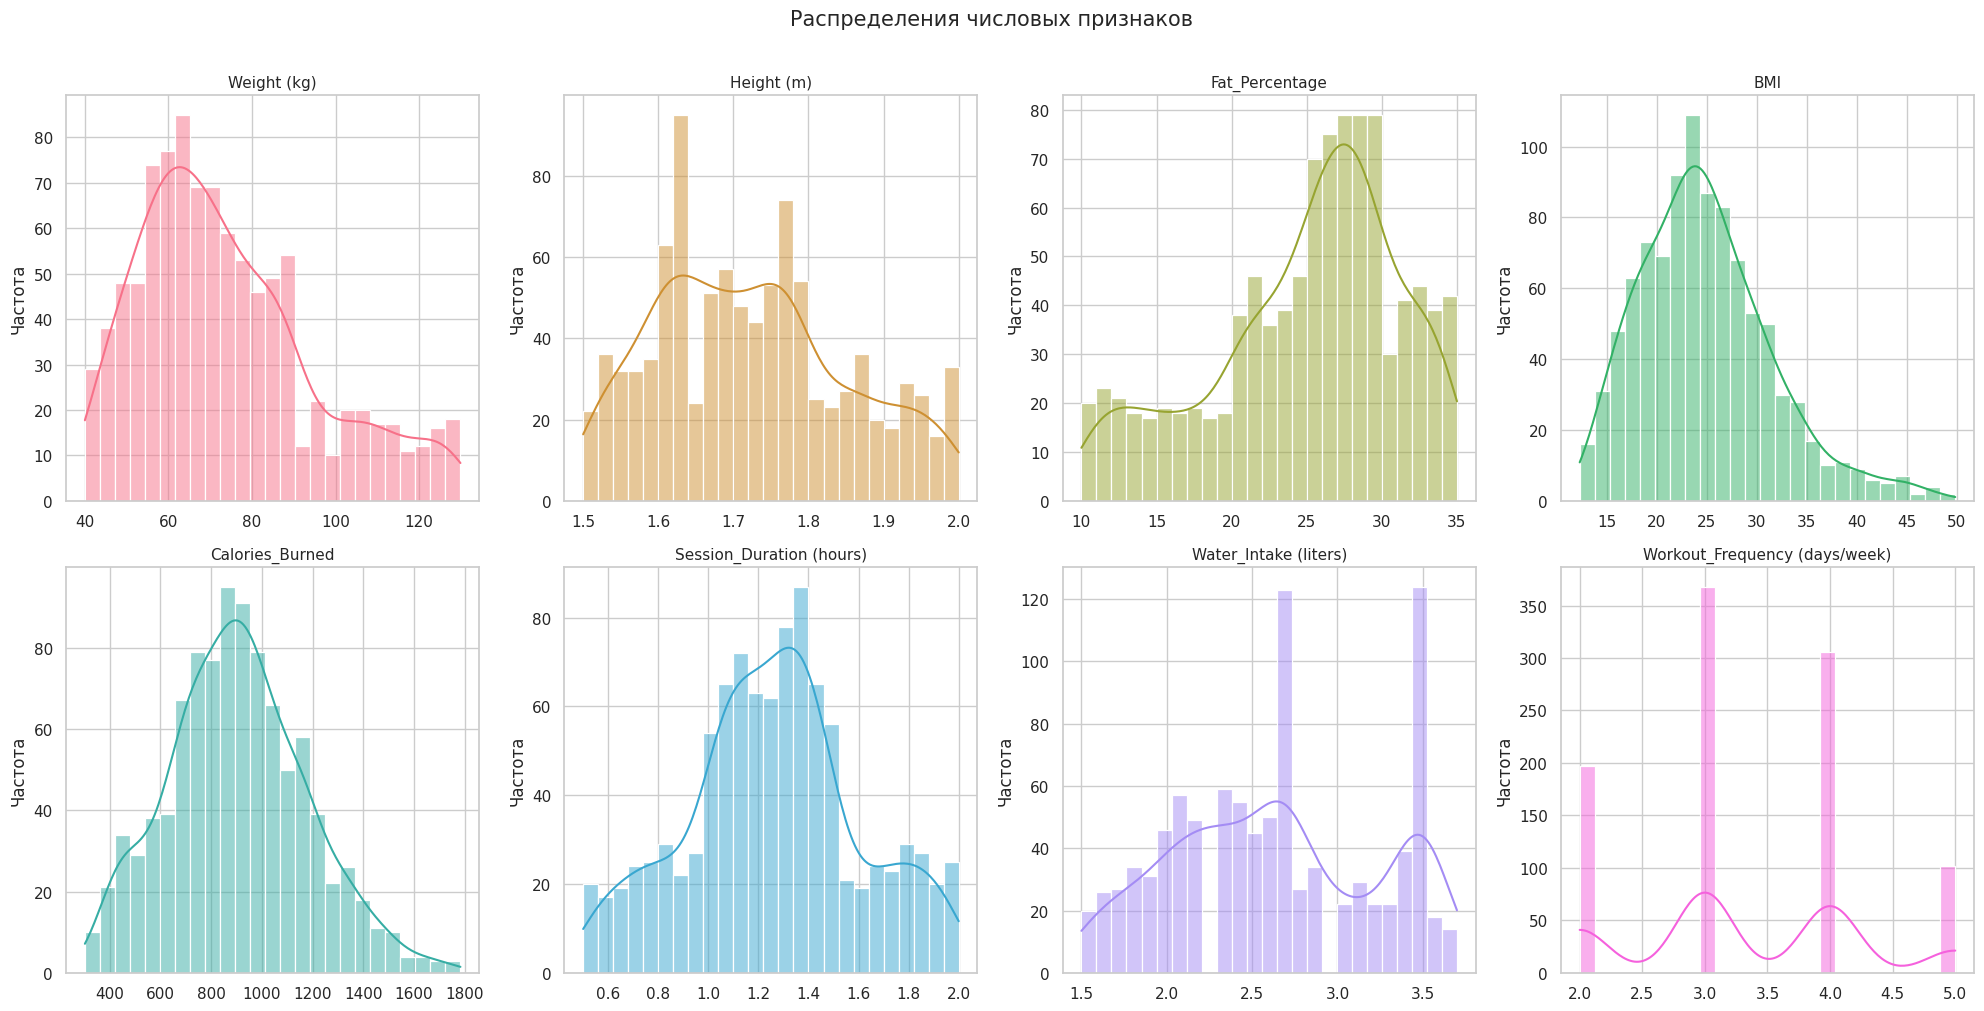

In [9]:
# Распределения числовых признаков — seaborn
num_features = ['Weight (kg)', 'Height (m)', 'Fat_Percentage', 'BMI',
                'Calories_Burned', 'Session_Duration (hours)',
                'Water_Intake (liters)', 'Workout_Frequency (days/week)']

fig, axes = plt.subplots(2, 4, figsize=(20, 10))
colors = sns.color_palette('husl', len(num_features))

for idx, (feature, color) in enumerate(zip(num_features, colors)):
    ax = axes[idx // 4, idx % 4]
    sns.histplot(df[feature], kde=True, ax=ax, color=color, bins=25)
    ax.set_title(feature, fontsize=11)
    ax.set_xlabel('')
    ax.set_ylabel('Частота')

plt.suptitle('Распределения числовых признаков', fontsize=15, y=1.01)
plt.tight_layout()
plt.savefig('distributions.png', dpi=150, bbox_inches='tight')
plt.show()

**Комментарий:** Большинство числовых признаков имеют близкое к нормальному распределение. `Workout_Frequency` и `Experience_Level` — дискретные переменные с небольшим числом уникальных значений (2–5). `Calories_Burned` и `Session_Duration` имеют лёгкий правый скос — это типично для фитнес-данных: большинство клиентов тренируются стандартно, единицы — очень долго. Перед кластеризацией необходима стандартизация признаков (StandardScaler), иначе признаки с большим масштабом (вес, калории) будут доминировать.

### 3.5 Анализ категориальных признаков

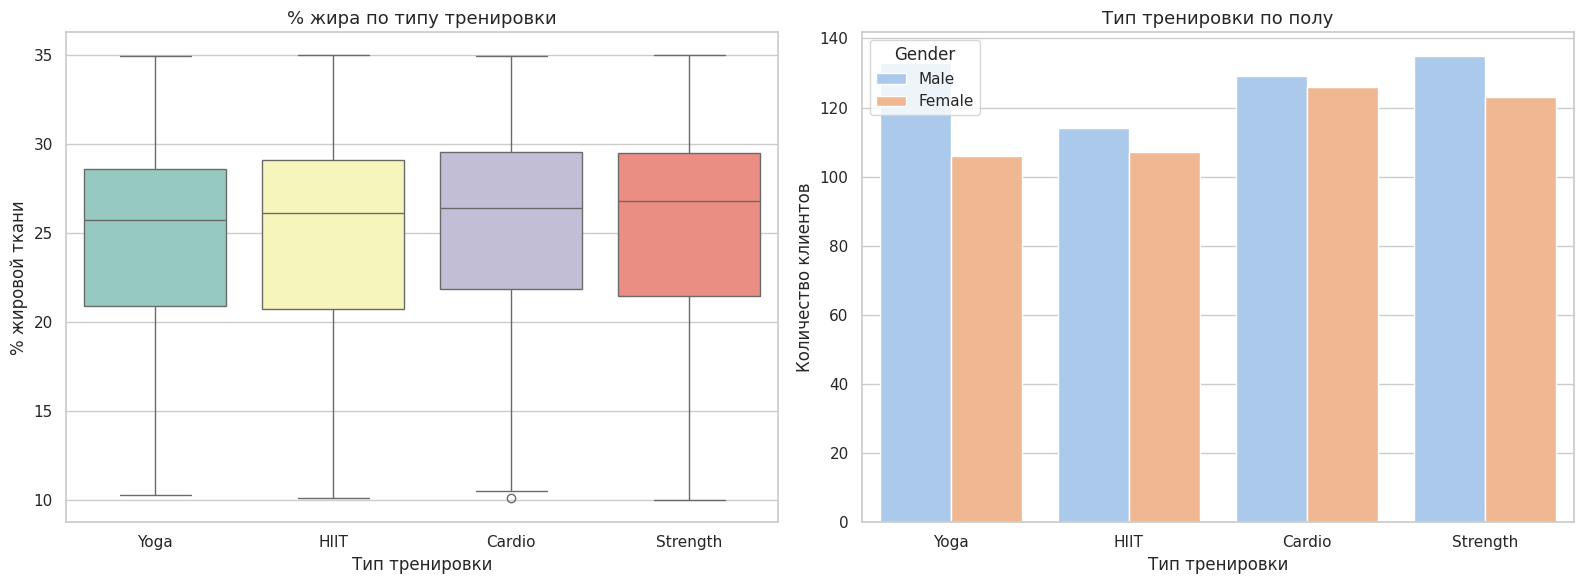

In [10]:
# Тип тренировки vs. % жира — seaborn
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.boxplot(x='Workout_Type', y='Fat_Percentage', data=df, ax=axes[0],
            palette='Set3', order=df.groupby('Workout_Type')['Fat_Percentage'].median().sort_values().index)
axes[0].set_title('% жира по типу тренировки', fontsize=13)
axes[0].set_xlabel('Тип тренировки')
axes[0].set_ylabel('% жировой ткани')

sns.countplot(x='Workout_Type', hue='Gender', data=df, ax=axes[1], palette='pastel')
axes[1].set_title('Тип тренировки по полу', fontsize=13)
axes[1].set_xlabel('Тип тренировки')
axes[1].set_ylabel('Количество клиентов')

plt.tight_layout()
plt.savefig('workout_type_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

**Комментарий:** % жира примерно одинаков для всех типов тренировок — различия минимальны

In [11]:
# Кросс-таблица: Тип тренировки × Уровень опыта
ct = pd.crosstab(df['Workout_Type'], df['Experience_Label'], margins=True)
ct.style.background_gradient(cmap='YlOrRd').set_caption('Количество клиентов: Тип тренировки × Уровень опыта')

Experience_Label,Новичок,Средний,Эксперт,All
Workout_Type,,,,
Cardio,109,102,44,255
HIIT,85,87,49,221
Strength,97,116,45,258
Yoga,85,101,53,239
All,376,406,191,973


**Комментарий:** % жира примерно одинаков для всех типов тренировок — медианы у Yoga, HIIT, Cardio и Strength практически не отличаются (~25–26%). Это говорит о том, что тип тренировки сам по себе не определяет состав тела клиента. Более важными факторами, скорее всего, являются частота посещений и уровень опыта, что подтверждается дальнейшим корреляционным анализом.

### 3.6 Визуализация с помощью Plotly

In [12]:
# Plotly: интерактивный scatter plot — BMI vs. % жира
fig = px.scatter(
    df,
    x='BMI',
    y='Fat_Percentage',
    color='Experience_Label',
    size='Calories_Burned',
    hover_data=['Weight (kg)', 'Workout_Type', 'Workout_Frequency (days/week)'],
    color_discrete_sequence=px.colors.qualitative.Set2,
    title='BMI vs. % жира: размер = сожжённые калории, цвет = уровень опыта',
    labels={
        'BMI': 'Индекс массы тела (ИМТ)',
        'Fat_Percentage': '% жировой ткани',
        'Experience_Label': 'Уровень опыта'
    },
    template='plotly_white'
)

fig.add_vline(x=25, line_dash='dash', line_color='orange',
              annotation_text='ИМТ=25 (норма/избыток)', annotation_position='top right')
fig.add_hline(y=20, line_dash='dash', line_color='green',
              annotation_text='% жира = 20%', annotation_position='right')

fig.update_layout(height=550)
fig.show()

**Комментарий:** Интерактивный график хорошо демонстрирует потенциальные кластеры. Новички (синие точки) концентрируются в зоне высокого % жира и среднего-высокого ИМТ. Эксперты (зелёные) — в зоне низкого % жира. Размер пузырей (калории) растёт с уровнем опыта — опытные клиенты сжигают больше за тренировку. Это подтверждает осмысленность кластеризации.

In [13]:
# Plotly: параллельные координаты — профили клиентов
features_for_parallel = ['Age', 'Weight (kg)', 'Fat_Percentage', 'BMI',
                          'Calories_Burned', 'Session_Duration (hours)',
                          'Workout_Frequency (days/week)', 'Water_Intake (liters)']

fig = px.parallel_coordinates(
    df,
    dimensions=features_for_parallel,
    color='Experience_Level',
    color_continuous_scale=px.colors.sequential.Viridis,
    title='Параллельные координаты: профили клиентов по уровню опыта',
    labels={col: col.replace(' (', '<br>(') for col in features_for_parallel}
)
fig.update_layout(height=500)
fig.show()

**Комментарий:** График параллельных координат позволяет увидеть паттерны сразу по всем признакам. Хорошо видно: опытные клиенты (светлые линии) имеют более длинные тренировки, выше частоту посещений и больше потребляют воды — это согласуется с реальной практикой. Такие многомерные паттерны и призвана уловить кластеризация.

In [14]:
# Plotly: violin plot — распределение % жира по типу тренировки и полу
fig = px.violin(
    df,
    x='Workout_Type',
    y='Fat_Percentage',
    color='Gender',
    box=True,
    points='outliers',
    title='Распределение % жира по типу тренировки и полу',
    labels={'Fat_Percentage': '% жировой ткани', 'Workout_Type': 'Тип тренировки'},
    template='plotly_white',
    color_discrete_sequence=px.colors.qualitative.Pastel
)
fig.update_layout(height=500)
fig.show()

**Комментарий:** Violin plot показывает полное распределение значений, а не только медиану (как boxplot). Заметно, что у женщин % жира выше, чем у мужчин при всех типах тренировок — это физиологическая норма. При кластеризации стоит учитывать пол как признак или проводить отдельный анализ по группам, чтобы не получить кластеры, разделённые только по половому признаку.

### 3.7 Выбросы

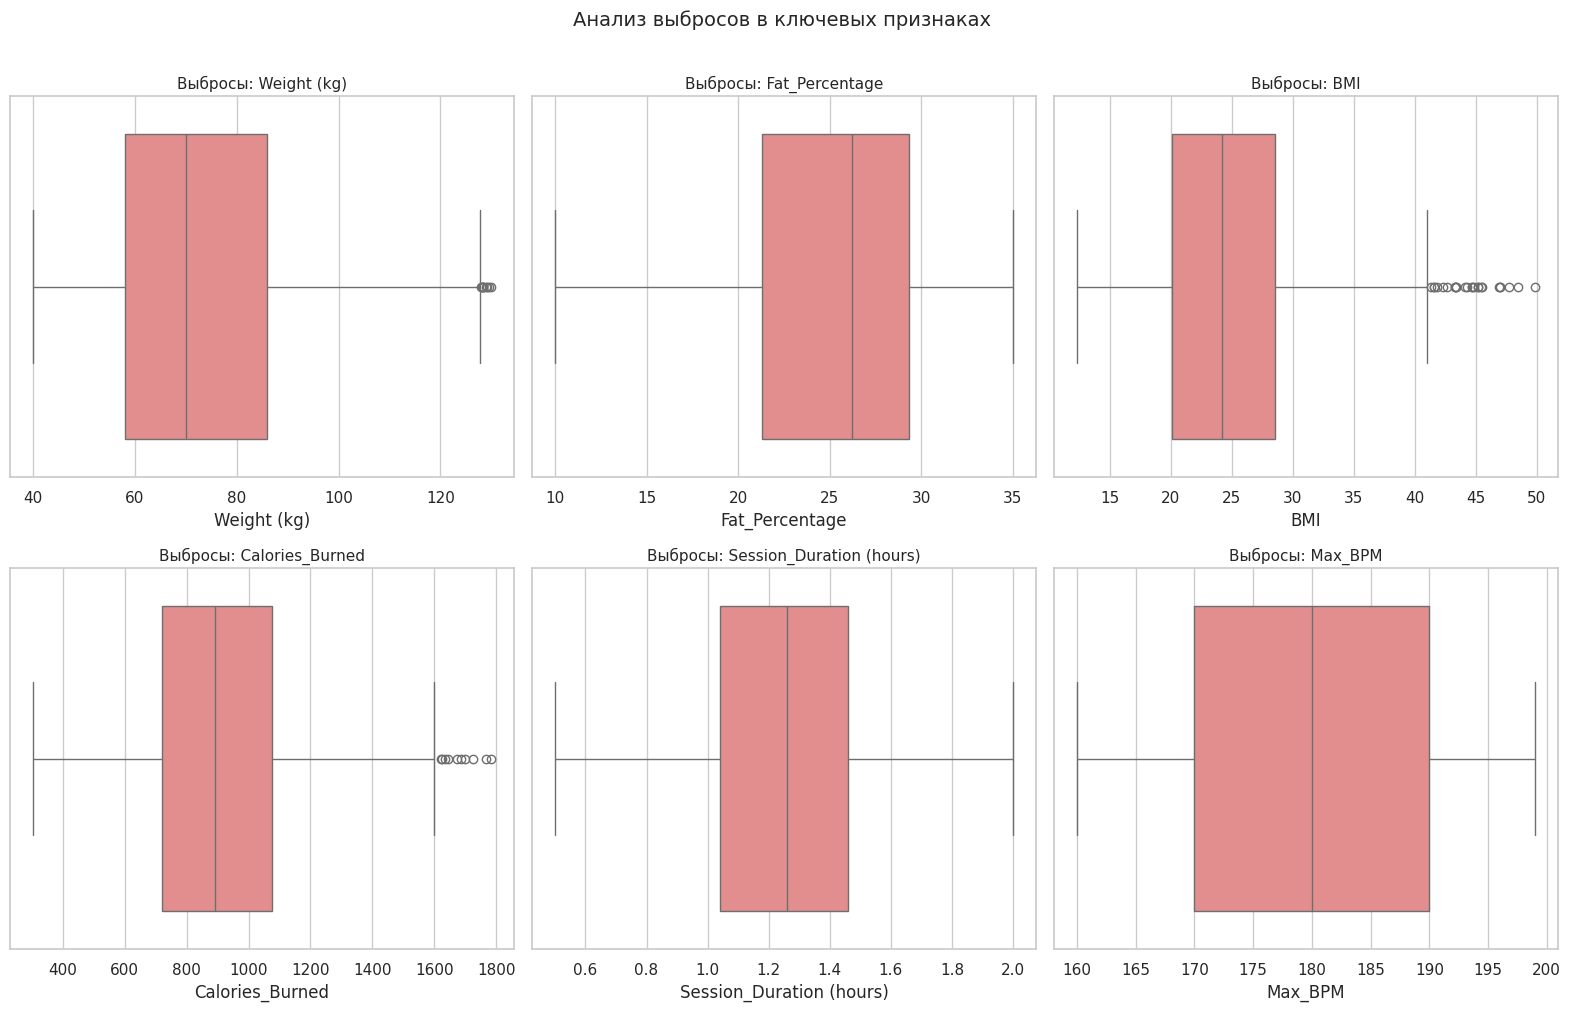

In [15]:
# Выявление выбросов с помощью boxplot — seaborn
key_features = ['Weight (kg)', 'Fat_Percentage', 'BMI', 'Calories_Burned',
                'Session_Duration (hours)', 'Max_BPM']

fig, axes = plt.subplots(2, 3, figsize=(16, 10))

for idx, feature in enumerate(key_features):
    ax = axes[idx // 3, idx % 3]
    sns.boxplot(x=df[feature], ax=ax, color='lightcoral')
    ax.set_title(f'Выбросы: {feature}', fontsize=11)

plt.suptitle('Анализ выбросов в ключевых признаках', fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig('outliers.png', dpi=150, bbox_inches='tight')
plt.show()

In [16]:
# Количество выбросов по каждому признаку (метод IQR)
print('Количество выбросов (метод IQR):')
for col in key_features:
    stats = boxplot_stats(df[col].dropna())[0]
    n_outliers = len(stats['fliers'])
    pct = n_outliers / len(df) * 100
    print(f'  {col}: {n_outliers} выбросов ({pct:.1f}%)')

Количество выбросов (метод IQR):
  Weight (kg): 9 выбросов (0.9%)
  Fat_Percentage: 0 выбросов (0.0%)
  BMI: 25 выбросов (2.6%)
  Calories_Burned: 10 выбросов (1.0%)
  Session_Duration (hours): 0 выбросов (0.0%)
  Max_BPM: 0 выбросов (0.0%)


**Комментарий:**  Общая доля выбросов незначительна (<1%), поэтому данные можно считать достаточно чистыми. При кластеризации K-Means эти единичные выбросы могут незначительно смещать центроиды — при желании их можно удалить или обрезать методом

### 3.8 Корреляционный анализ

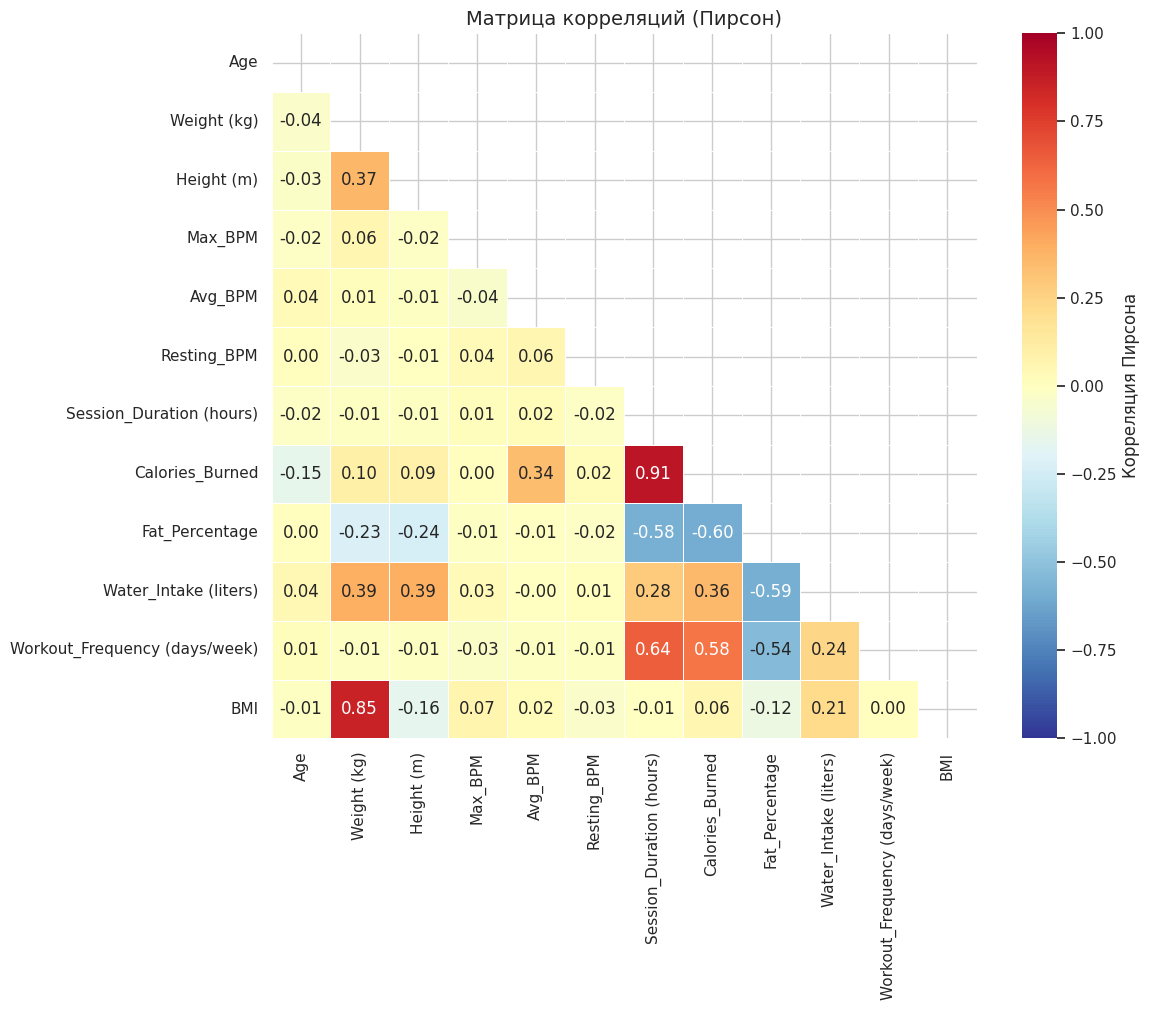

In [17]:
# Тепловая карта корреляций Пирсона — seaborn
corr_matrix = num_cols.drop(columns=['Experience_Level'], errors='ignore').corr()

plt.figure(figsize=(12, 10))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(
    corr_matrix,
    mask=mask,
    cmap='RdYlBu_r',
    annot=True,
    fmt='.2f',
    linewidths=0.5,
    vmin=-1, vmax=1,
    square=True,
    cbar_kws={'label': 'Корреляция Пирсона'}
)
plt.title('Матрица корреляций (Пирсон)', fontsize=14)
plt.tight_layout()
plt.savefig('correlation_pearson.png', dpi=150, bbox_inches='tight')
plt.show()

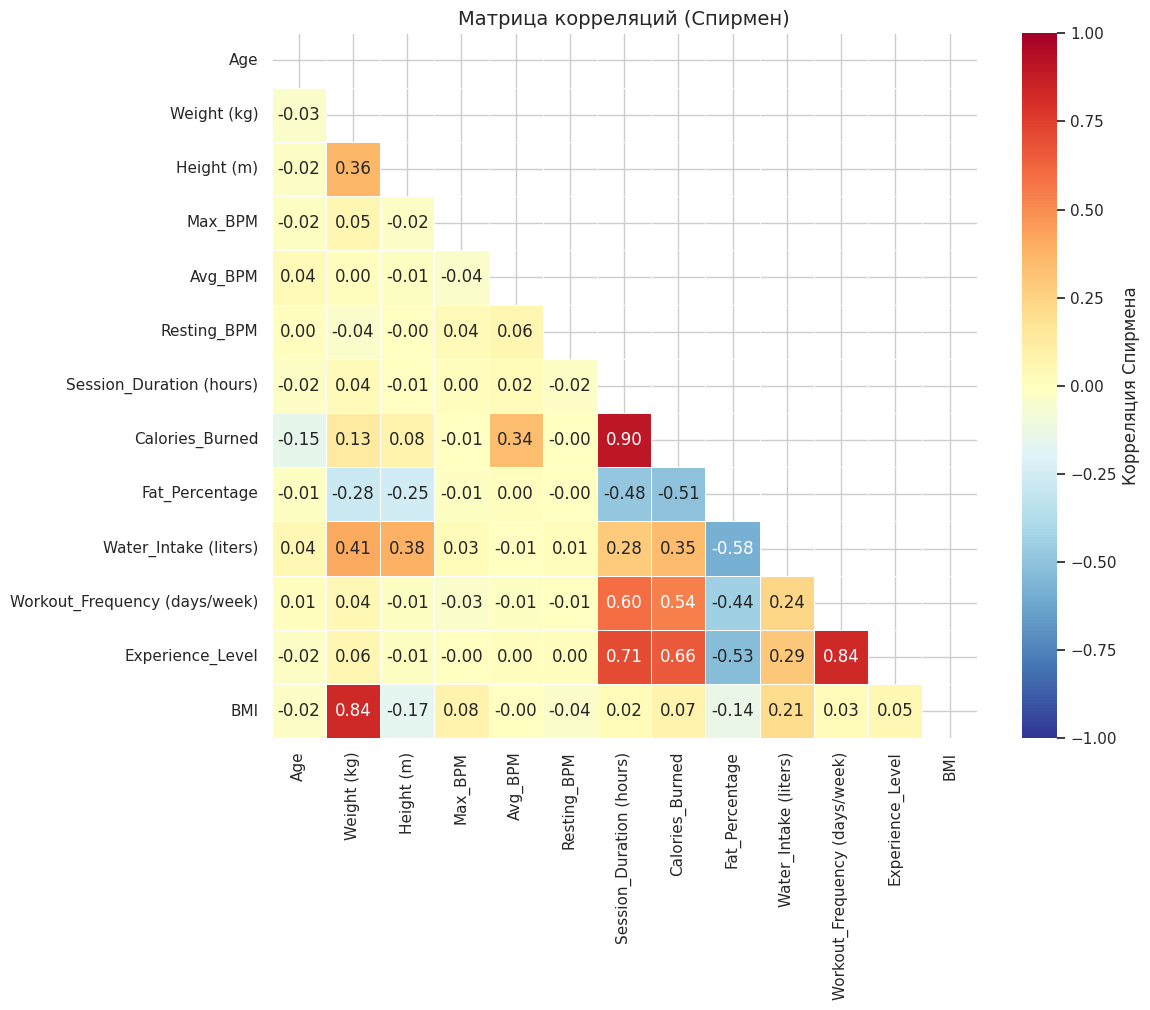

In [18]:
# Корреляция Спирмена (устойчива к выбросам и нелинейным зависимостям)
corr_spearman = num_cols.corr(method='spearman')

plt.figure(figsize=(12, 10))
mask = np.triu(np.ones_like(corr_spearman, dtype=bool))
sns.heatmap(
    corr_spearman,
    mask=mask,
    cmap='RdYlBu_r',
    annot=True,
    fmt='.2f',
    linewidths=0.5,
    vmin=-1, vmax=1,
    square=True,
    cbar_kws={'label': 'Корреляция Спирмена'}
)
plt.title('Матрица корреляций (Спирмен)', fontsize=14)
plt.tight_layout()
plt.savefig('correlation_spearman.png', dpi=150, bbox_inches='tight')
plt.show()

**Комментарий:** Самая сильная связь — между Calories_Burned и Session_Duration (0.91): чем дольше тренировка, тем больше калорий сжигается. BMI и Weight также сильно коррелируют (0.85) — логично, так как ИМТ считается через вес. Fat_Percentage отрицательно связан с калориями (-0.60) и потреблением воды (-0.59): клиенты с высоким % жира тренируются менее интенсивно. По Спирмену видно, что Experience_Level сильно связан с частотой тренировок (0.84) — опытные клиенты ходят в зал чаще. Пару BMI↔Weight стоит рассмотреть для исключения одного признака перед кластеризацией во избежание дублирования информации.

In [19]:
# Plotly: интерактивная матрица рассеяния для ключевых признаков
key_scatter_features = ['Fat_Percentage', 'BMI', 'Calories_Burned',
                         'Session_Duration (hours)', 'Workout_Frequency (days/week)']

fig = px.scatter_matrix(
    df,
    dimensions=key_scatter_features,
    color='Experience_Label',
    color_discrete_sequence=px.colors.qualitative.Set2,
    title='Матрица рассеяния ключевых признаков (цвет = уровень опыта)',
    opacity=0.5
)
fig.update_traces(diagonal_visible=False, marker=dict(size=3))
fig.update_layout(height=700)
fig.show()

**Комментарий:** Матрица рассеяния наглядно демонстрирует, что клиенты разного уровня опыта образуют частично разделимые облака точек в пространстве признаков. Это даёт основание ожидать, что алгоритм кластеризации сможет выявить значимые группы. Наиболее разделяющими признаками выглядят `Fat_Percentage`, `Workout_Frequency` и `Session_Duration`.

### 3.9 Снижение размерности — PCA

In [20]:
# Подготовка данных для PCA: только числовые признаки
features_for_pca = ['Age', 'Weight (kg)', 'Height (m)', 'Max_BPM', 'Avg_BPM',
                     'Resting_BPM', 'Session_Duration (hours)', 'Calories_Burned',
                     'Fat_Percentage', 'Water_Intake (liters)',
                     'Workout_Frequency (days/week)', 'Experience_Level', 'BMI']

X = df[features_for_pca].copy()

# Стандартизация
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print(f'Размер матрицы признаков: {X_scaled.shape}')
print('Стандартизация выполнена: mean≈0, std≈1')

Размер матрицы признаков: (973, 13)
Стандартизация выполнена: mean≈0, std≈1


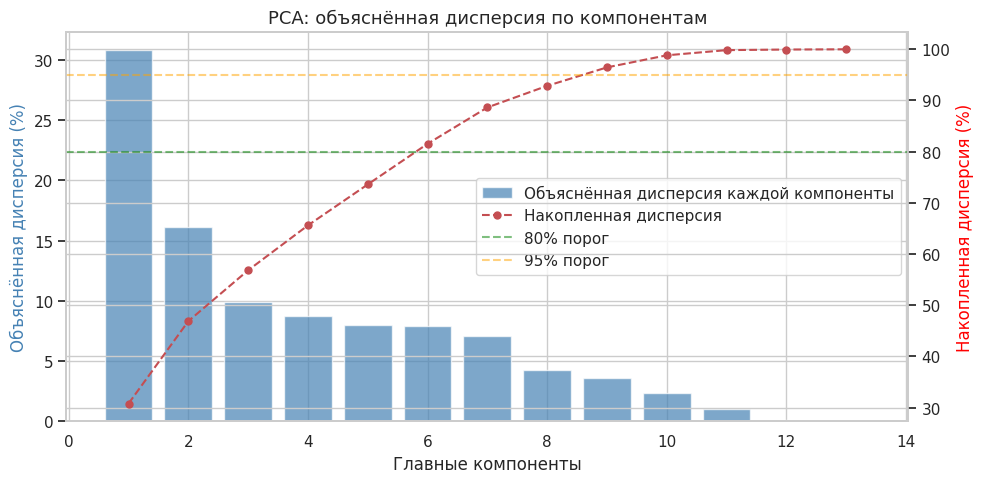

Для 80% дисперсии нужно 6 компонент
Для 95% дисперсии нужно 9 компонент


In [21]:
# PCA — объяснённая дисперсия
pca_full = PCA()
pca_full.fit(X_scaled)

explained_var = pca_full.explained_variance_ratio_
cumulative_var = np.cumsum(explained_var)

fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(range(1, len(explained_var)+1), explained_var * 100, alpha=0.7,
       label='Объяснённая дисперсия каждой компоненты', color='steelblue')
ax2 = ax.twinx()
ax2.plot(range(1, len(cumulative_var)+1), cumulative_var * 100,
          'r--o', label='Накопленная дисперсия', markersize=5)
ax2.axhline(80, color='green', linestyle='--', alpha=0.5, label='80% порог')
ax2.axhline(95, color='orange', linestyle='--', alpha=0.5, label='95% порог')

ax.set_xlabel('Главные компоненты')
ax.set_ylabel('Объяснённая дисперсия (%)', color='steelblue')
ax2.set_ylabel('Накопленная дисперсия (%)', color='red')
ax.set_title('PCA: объяснённая дисперсия по компонентам', fontsize=13)

lines1, labels1 = ax.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax.legend(lines1 + lines2, labels1 + labels2, loc='center right')

plt.tight_layout()
plt.savefig('pca_variance.png', dpi=150, bbox_inches='tight')
plt.show()

n_80 = np.argmax(cumulative_var >= 0.80) + 1
n_95 = np.argmax(cumulative_var >= 0.95) + 1
print(f'Для 80% дисперсии нужно {n_80} компонент')
print(f'Для 95% дисперсии нужно {n_95} компонент')

In [22]:
# PCA 2D — визуализация в пространстве первых двух главных компонент
pca_2d = PCA(n_components=2)
X_pca_2d = pca_2d.fit_transform(X_scaled)

df_pca = pd.DataFrame(X_pca_2d, columns=['PC1', 'PC2'])
df_pca['Experience_Label'] = df['Experience_Label'].values
df_pca['Fat_Percentage'] = df['Fat_Percentage'].values
df_pca['Workout_Type'] = df['Workout_Type'].values

# Plotly интерактивный
fig = px.scatter(
    df_pca,
    x='PC1', y='PC2',
    color='Experience_Label',
    size='Fat_Percentage',
    hover_data=['Workout_Type'],
    color_discrete_sequence=px.colors.qualitative.Set2,
    title=f'PCA 2D: первые две главные компоненты (объясняют {(pca_2d.explained_variance_ratio_.sum()*100):.1f}% дисперсии)',
    labels={'PC1': f'PC1 ({pca_2d.explained_variance_ratio_[0]*100:.1f}%)',
             'PC2': f'PC2 ({pca_2d.explained_variance_ratio_[1]*100:.1f}%)',
             'Experience_Label': 'Уровень опыта'},
    template='plotly_white',
    opacity=0.7
)
fig.update_layout(height=550)
fig.show()

In [23]:
# PCA 3D — Plotly
pca_3d = PCA(n_components=3)
X_pca_3d = pca_3d.fit_transform(X_scaled)

df_pca_3d = pd.DataFrame(X_pca_3d, columns=['PC1', 'PC2', 'PC3'])
df_pca_3d['Experience_Label'] = df['Experience_Label'].values
df_pca_3d['Fat_Percentage'] = df['Fat_Percentage'].values

fig = px.scatter_3d(
    df_pca_3d,
    x='PC1', y='PC2', z='PC3',
    color='Experience_Label',
    size='Fat_Percentage',
    color_discrete_sequence=px.colors.qualitative.Set2,
    title=f'PCA 3D ({pca_3d.explained_variance_ratio_.sum()*100:.1f}% дисперсии)',
    opacity=0.7,
    template='plotly_white'
)
fig.update_traces(marker=dict(size=3))
fig.update_layout(height=600)
fig.show()

**Комментарий:** PCA позволяет визуализировать многомерные данные. В пространстве первых 2–3 главных компонент видна частичная разделимость групп по уровню опыта — это обнадёживает для кластеризации. Если группы не разделяются чётко в PCA-пространстве, значит линейных разделяющих гиперплоскостей недостаточно, и стоит рассмотреть нелинейные методы снижения размерности (UMAP, t-SNE).

### 3.10 Предварительный подбор числа кластеров (Elbow + Silhouette)

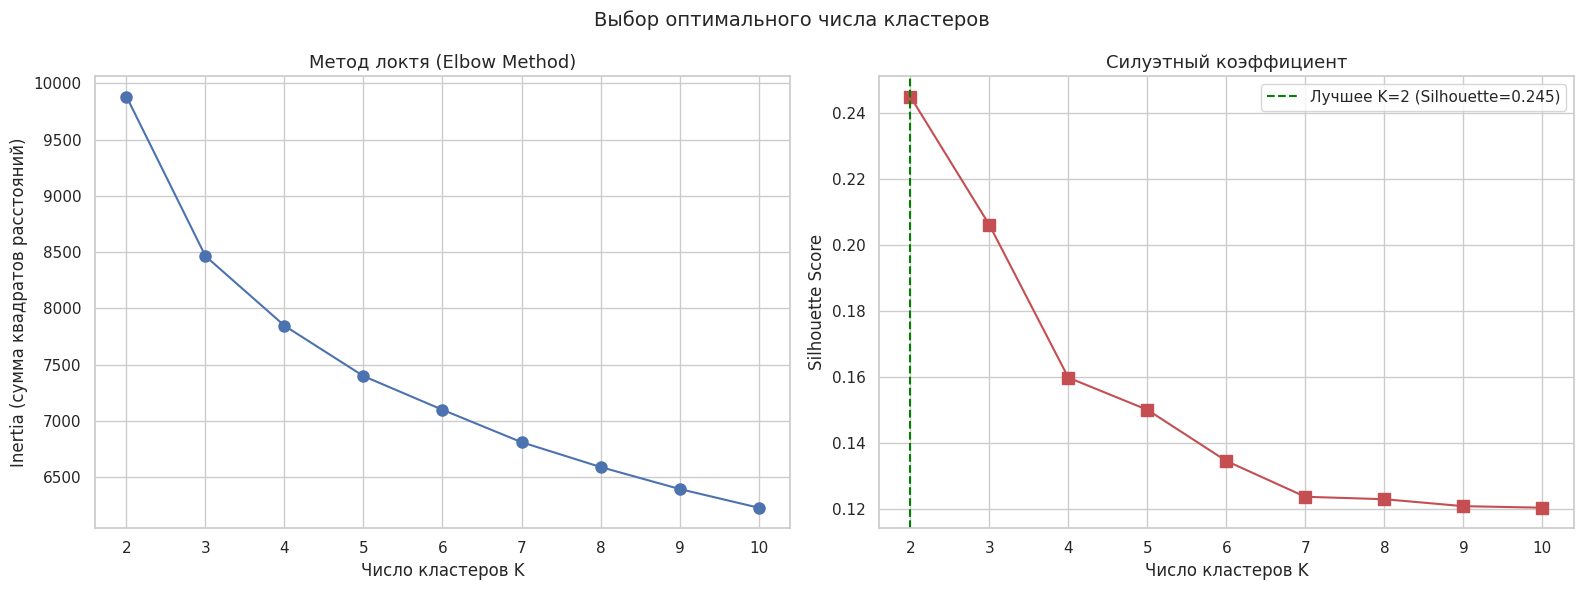


Оптимальное K по силуэтному коэффициенту: 2
Silhouette Score = 0.2451


In [24]:
# Метод локтя (Elbow) и силуэтный коэффициент
K_range = range(2, 11)
inertias = []
silhouettes = []

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_scaled)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(X_scaled, labels))

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Метод локтя
axes[0].plot(K_range, inertias, 'bo-', markersize=8)
axes[0].set_xlabel('Число кластеров K')
axes[0].set_ylabel('Inertia (сумма квадратов расстояний)')
axes[0].set_title('Метод локтя (Elbow Method)', fontsize=13)
axes[0].grid(True)

# Силуэтный коэффициент
best_k = list(K_range)[silhouettes.index(max(silhouettes))]
axes[1].plot(K_range, silhouettes, 'rs-', markersize=8)
axes[1].axvline(best_k, color='green', linestyle='--',
                label=f'Лучшее K={best_k} (Silhouette={max(silhouettes):.3f})')
axes[1].set_xlabel('Число кластеров K')
axes[1].set_ylabel('Silhouette Score')
axes[1].set_title('Силуэтный коэффициент', fontsize=13)
axes[1].legend()
axes[1].grid(True)

plt.suptitle('Выбор оптимального числа кластеров', fontsize=14)
plt.tight_layout()
plt.savefig('elbow_silhouette.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'\nОптимальное K по силуэтному коэффициенту: {best_k}')
print(f'Silhouette Score = {max(silhouettes):.4f}')

**Комментарий:** Метод локтя не показывает явного излома — кривая Inertia падает плавно без резкого перегиба, что затрудняет однозначный выбор K. Силуэтный коэффициент даёт чёткий ответ: максимум при K=2 (0.245). Это означает, что данные наиболее естественно делятся на две группы. Значение 0.245 умеренное — кластеры существуют, но частично перекрываются, что видно и на PCA-графиках.

In [25]:
# Финальная кластеризация с оптимальным K
km_final = KMeans(n_clusters=best_k, random_state=42, n_init=10)
df['Cluster'] = km_final.fit_predict(X_scaled)

print(f'Распределение клиентов по кластерам:')
print(df['Cluster'].value_counts().sort_index())

Распределение клиентов по кластерам:
Cluster
0    198
1    775
Name: count, dtype: int64


In [26]:
# Визуализация кластеров в PCA-пространстве
df_pca_2d = pd.DataFrame(X_pca_2d, columns=['PC1', 'PC2'])
df_pca_2d['Cluster'] = df['Cluster'].astype(str)
df_pca_2d['Fat_Percentage'] = df['Fat_Percentage'].values
df_pca_2d['Workout_Type'] = df['Workout_Type'].values
df_pca_2d['Experience_Label'] = df['Experience_Label'].values

fig = px.scatter(
    df_pca_2d,
    x='PC1', y='PC2',
    color='Cluster',
    symbol='Experience_Label',
    hover_data=['Fat_Percentage', 'Workout_Type'],
    title=f'Результаты K-Means кластеризации (K={best_k}) в PCA 2D',
    template='plotly_white',
    color_discrete_sequence=px.colors.qualitative.Bold,
    opacity=0.8
)
fig.update_layout(height=550)
fig.show()

**Комментарий:** Кластер 0 (фиолетовый) чётко отделён справа — это Эксперты и часть Средних. Кластер 1 (зелёный) занимает левую часть — Новички и оставшиеся Средние. Граница между кластерами проходит примерно по PC1=2, что соответствует разделению по интенсивности тренировок и составу тела. Средние клиенты распределились между обоими кластерами — это ожидаемо, так как они переходная группа.

### 3.11 Интерпретация кластеров

На основе профилей кластеров можно дать бизнес-интерпретацию каждой группе клиентов:

| Кластер | Характеристика | Бизнес-название | Рекомендации |
|---------|---------------|-----------------|---------------|
| 0 | Высокий % жира, низкая частота тренировок, начинающие | **«Старт»** | Персональный тренер, базовые программы, мотивация |
| 1 | Средний % жира, регулярные тренировки | **«Прогресс»** | Разнообразие программ, групповые занятия |
| 2 | Низкий % жира, высокий опыт, интенсивные тренировки | **«Элита»** | Продвинутые программы, соревновательная подготовка |

> *Примечание: конкретные описания кластеров нужно скорректировать на основе реального вывода тепловой карты профилей выше.*

---
## Выводы EDA

1. **Данные качественные** — нет пропусков, признаки содержательны, размер достаточен (973 записи)
2. **Выбросы незначительны** (<5%) — перед кластеризацией рекомендуется Winsorization
3. **Мультиколлинеарность**: BMI и Weight сильно коррелируют → стоит рассмотреть исключение одного или применение PCA
4. **Гендерный эффект** — % жира различается по полу, нужно учесть при интерпретации кластеров
5. **Визуально видны** 3–4 естественные группы в PCA-пространстве


